In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\kevin\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\kevin\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\kevin\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_lo

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\kevin\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\kevin\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\kevin\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_lo

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [2]:
df=pd.read_csv('cleanenddata1.csv',index_col=0)
df.head()

,brands,code,product_name,energy_kcal_value,energy_kj_value,carbohydrates_value,sugars_value,fat_value,saturated_fat_value,proteins_value,salt_value,sodium_value,nova_group,nutrition_score_fr,fruits_vegetables_nuts_estimate_from_ingredients_100g
0,sidi ali,6111035000430,sidi ali,0.0,20.0,42.0,14.0,0.0,0.00,0.0,0.00000,0.000000,1.0,1.0,0.0
1,jaouda,6111242100992,perly,97.0,406.0,9.4,7.5,3.0,1.15,8.0,0.00000,0.000000,3.0,4.0,0.0
2,sidi ali,6111035002175,sidi ali,0.0,20.0,42.0,14.0,0.0,0.00,0.0,65.00000,26.000000,1.0,0.0,0.0
3,les eaux minrales doulmssidi ali,6111035000058,eau minrale naturelle,0.0,0.0,0.0,0.0,0.0,0.00,0.0,65.00000,26.000000,1.0,0.0,0.0
4,aquafina,6111252421568,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00508,0.002032,1.0,0.0,0.0


In [ ]:
"""
Key Nutritional Indicators:
Feature--->Meaning--->Health Relevance
energy-kcal_value--->Calories per 100g--->High calories → obesity risk if consumed excessively
carbohydrates_value--->Total carbs per 100g--->Includes sugars + starches
sugars_value--->Sugar per 100g--->High sugar → diabetes, dental issues
sugar_to_carb_ratio--->Ratio of sugar to total carbs--->Higher ratio → more added sugars
fat_value, saturated-fat_value--->Total and saturated fats--->High saturated fat → heart risks
proteins_value--->Protein per 100g--->Beneficial nutrient
nova-group--->Food processing classification (1-4)--->1: Unprocessed → 4: Ultra-processed
nutrition-score-fr--->Healthiness score (lower = healthier)--->European Nutri-Score metric
calorie_category, sugar_category--->Derived labels (e.g. “Low”, “Medium”, “High”)--->Easier for grouping
is_ultra_processed--->Boolean (True if NOVA=4)--->Used to assess food processing risk
"""

In [8]:

# 1️⃣ sugar_to_carb_ratio
# # Safely calculate ratio, avoid division by zero
df['sugar_to_carb_ratio'] = df.apply(
    lambda row: row['sugars_value'] / row['carbohydrates_value']
    if pd.notnull(row['sugars_value']) and pd.notnull(row['carbohydrates_value']) and row['carbohydrates_value'] != 0
    else np.nan,
    axis=1
)

# 2️⃣ calorie_category (energy-kcal_value)
# Example thresholds (per 100g)
def calorie_class(kcal):
    if pd.isnull(kcal):
        return np.nan
    elif kcal < 40:
        return 'Low'
    elif 40 <= kcal <= 100:
        return 'Moderate'
    else:
        return 'High'

df['calorie_category'] = df['energy_kcal_value'].apply(calorie_class)

# 3️⃣ sugar_category (sugars_value)
def sugar_class(sugar):
    if pd.isnull(sugar):
        return np.nan
    elif sugar < 5:
        return 'Low Sugar'
    elif 5 <= sugar <= 22.5:
        return 'Moderate Sugar'
    else:
        return 'High Sugar'

df['sugar_category'] = df['sugars_value'].apply(sugar_class)

# 4️⃣ is_ultra_processed (nova-group)
# Flag as 'Yes' if nova-group == 4, else 'No'
df['is_ultra_processed'] = df['nova_group'].apply(
    lambda x: 'Yes' if x == 4 else ('No' if pd.notnull(x) else np.nan)
)
df.head()

,brands,code,product_name,energy_kcal_value,energy_kj_value,carbohydrates_value,sugars_value,fat_value,saturated_fat_value,proteins_value,salt_value,sodium_value,nova_group,nutrition_score_fr,fruits_vegetables_nuts_estimate_from_ingredients_100g,sugar_to_carb_ratio,calorie_category,sugar_category,is_ultra_processed
0,sidi ali,6111035000430,sidi ali,0.0,20.0,42.0,14.0,0.0,0.00,0.0,0.00000,0.000000,1.0,1.0,0.0,0.333333,Low,Moderate Sugar,No
1,jaouda,6111242100992,perly,97.0,406.0,9.4,7.5,3.0,1.15,8.0,0.00000,0.000000,3.0,4.0,0.0,0.797872,Moderate,Moderate Sugar,No
2,sidi ali,6111035002175,sidi ali,0.0,20.0,42.0,14.0,0.0,0.00,0.0,65.00000,26.000000,1.0,0.0,0.0,0.333333,Low,Moderate Sugar,No
3,les eaux minrales doulmssidi ali,6111035000058,eau minrale naturelle,0.0,0.0,0.0,0.0,0.0,0.00,0.0,65.00000,26.000000,1.0,0.0,0.0,NaN,Low,Low Sugar,No
4,aquafina,6111252421568,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00508,0.002032,1.0,0.0,0.0,NaN,Low,Low Sugar,No


Text(0.5, 1.0, 'Correlation Heatmap')

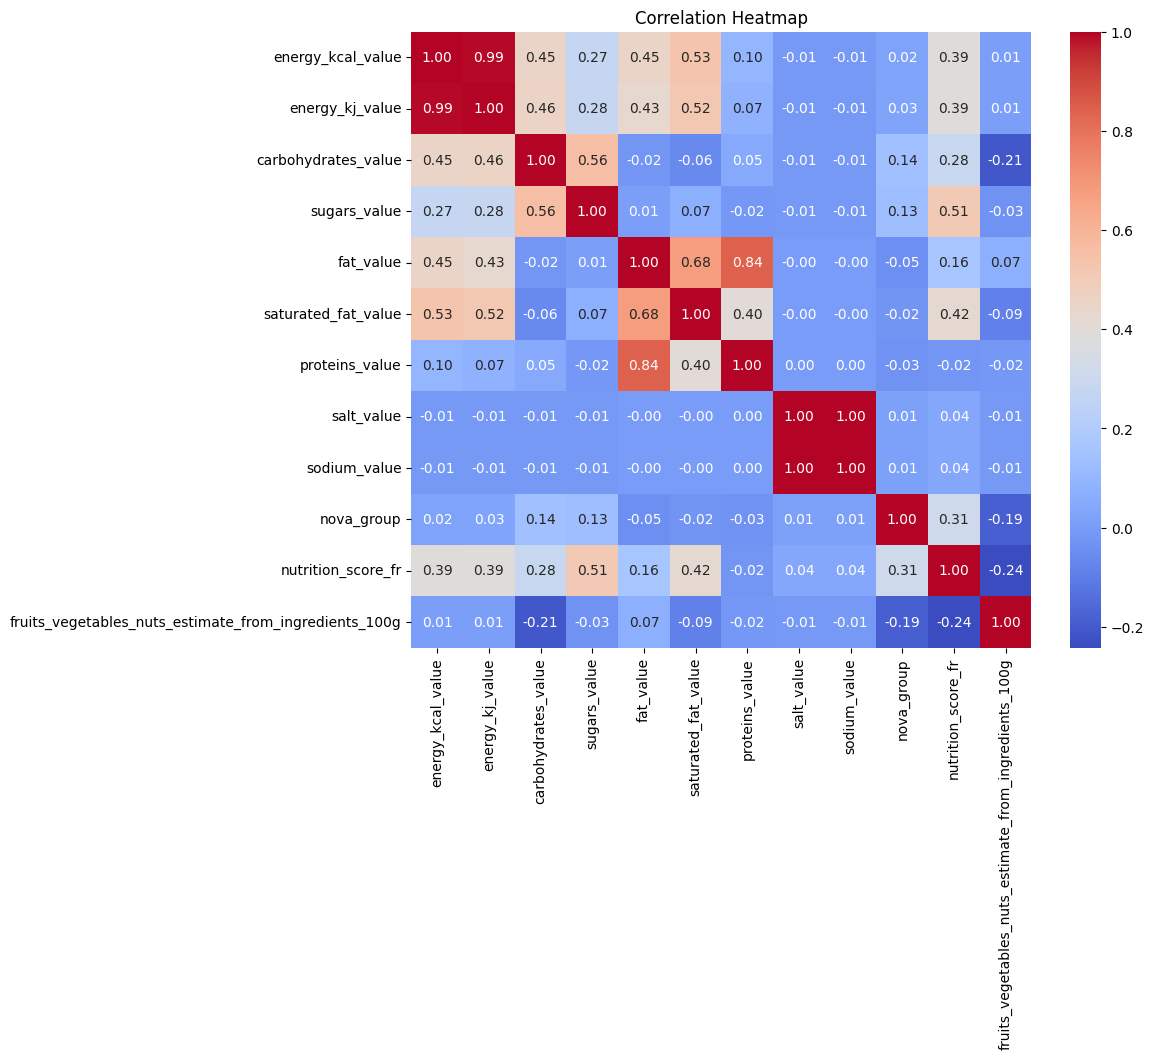

In [9]:
correlation_matrix=df.iloc[:,3:-4]
correlation_matrix=correlation_matrix.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap='coolwarm')
plt.title('Correlation Heatmap')

In [10]:
nutrients_columns=['energy_kcal_value',
       'energy_kj_value', 'carbohydrates_value', 'sugars_value', 'fat_value',
       'saturated_fat_value', 'proteins_value', 'salt_value', 'sodium_value',
        'nutrition_score_fr',
       'fruits_vegetables_nuts_estimate_from_ingredients_100g']

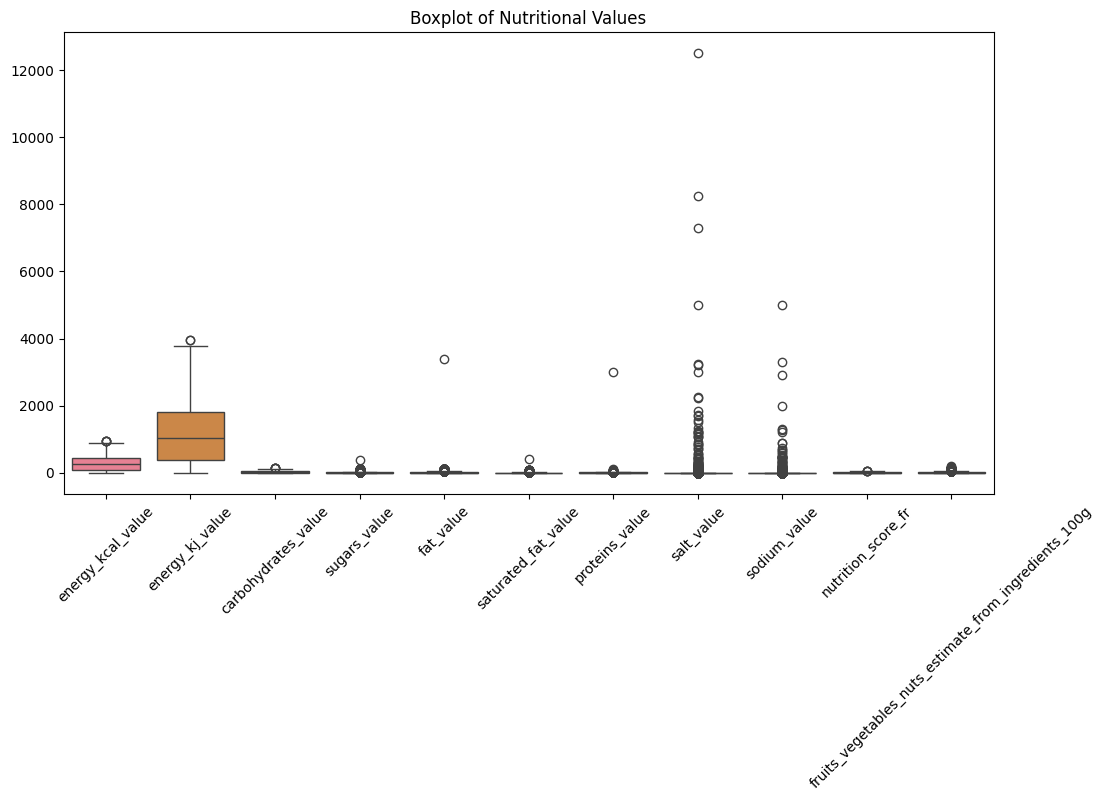

In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[nutrients_columns])
plt.xticks(rotation=45)
plt.title("Boxplot of Nutritional Values")
plt.show()


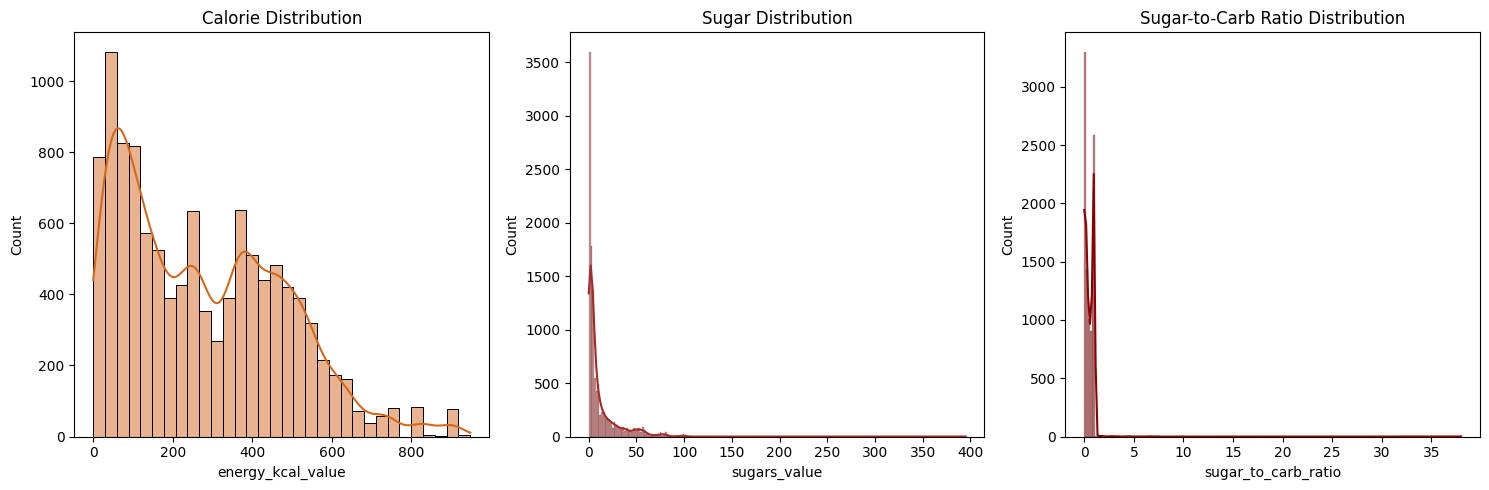

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
sns.histplot(df['energy_kcal_value'], kde=True, ax=axes[0], color='chocolate')
sns.histplot(df['sugars_value'], kde=True, ax=axes[1], color='brown')
sns.histplot(df['sugar_to_carb_ratio'], kde=True, ax=axes[2], color='darkred')
axes[0].set_title("Calorie Distribution")
axes[1].set_title("Sugar Distribution")
axes[2].set_title("Sugar-to-Carb Ratio Distribution")
plt.tight_layout()
plt.show()


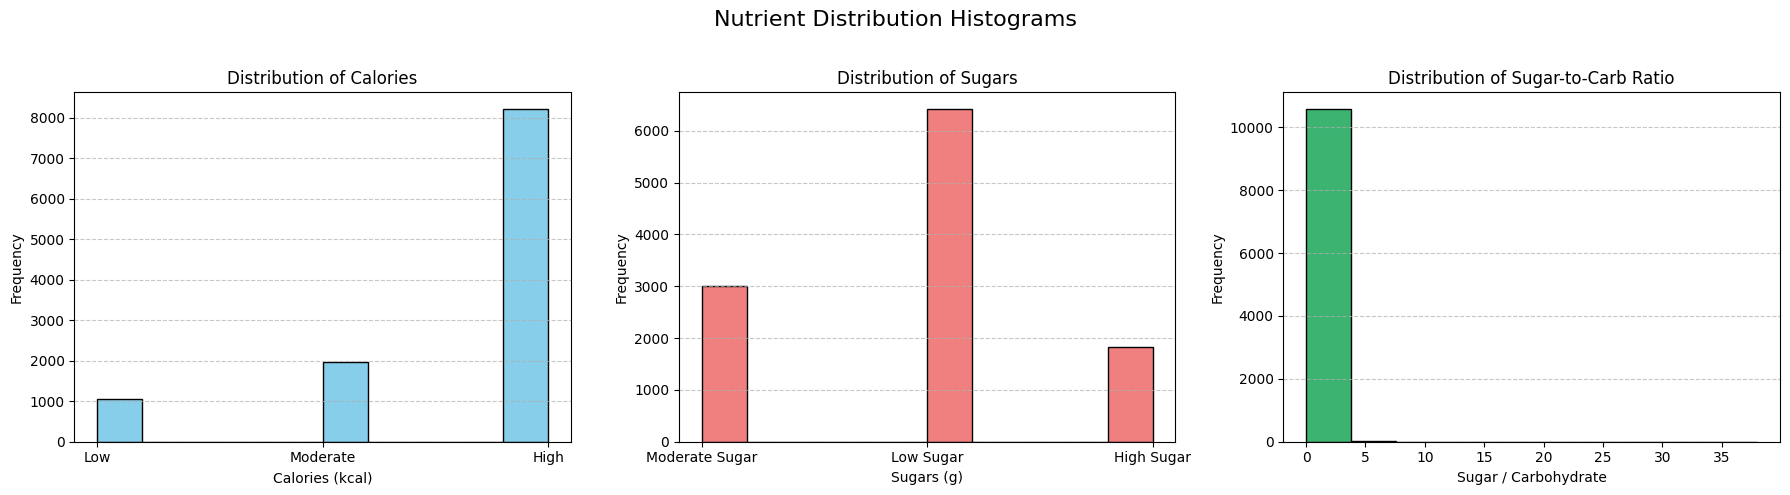

In [14]:
# Set up the plot with multiple subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Nutrient Distribution Histograms', fontsize=16)

# Histogram for Calories
axs[0].hist(df['calorie_category'], bins=10, edgecolor='black', color='skyblue')
axs[0].set_title('Distribution of Calories')
axs[0].set_xlabel('Calories (kcal)')
axs[0].set_ylabel('Frequency')
axs[0].grid(axis='y', linestyle='--', alpha=0.7)

# Histogram for Sugars
axs[1].hist(df['sugar_category'], bins=10, edgecolor='black', color='lightcoral')
axs[1].set_title('Distribution of Sugars')
axs[1].set_xlabel('Sugars (g)')
axs[1].set_ylabel('Frequency')
axs[1].grid(axis='y', linestyle='--', alpha=0.7)

# Histogram for Sugar-to-Carb Ratio
axs[2].hist(df['sugar_to_carb_ratio'], bins=10, edgecolor='black', color='mediumseagreen')
axs[2].set_title('Distribution of Sugar-to-Carb Ratio')
axs[2].set_xlabel('Sugar / Carbohydrate')
axs[2].set_ylabel('Frequency')
axs[2].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to prevent titles from overlapping
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Display the plot
plt.show()


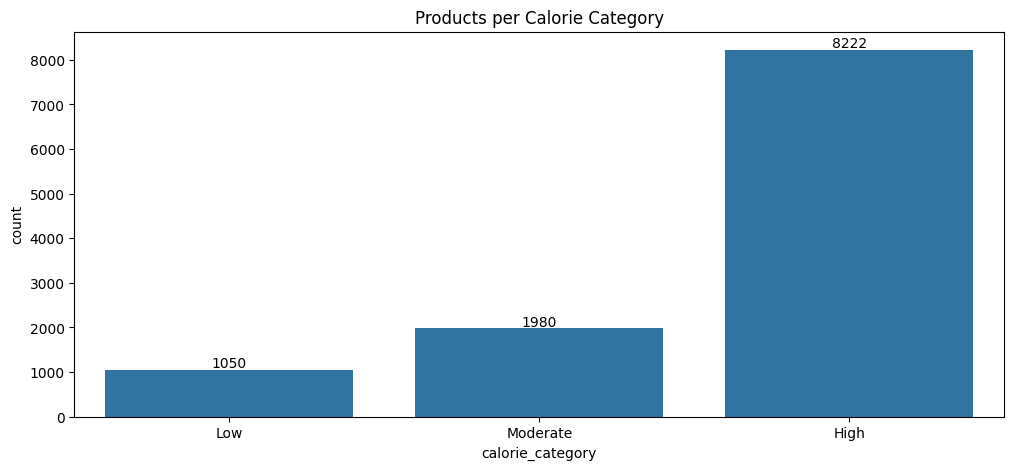

In [15]:
plt.figure(figsize=(12,5))
ax = sns.countplot(data=df, x='calorie_category')
plt.title("Products per Calorie Category")

# Add counts on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 50,
            int(height), ha="center", fontsize=10)

plt.show()


C:\Users\kevin\AppData\Local\Temp\ipykernel_22828\3778202167.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=df, x='sugar_category', palette='magma')


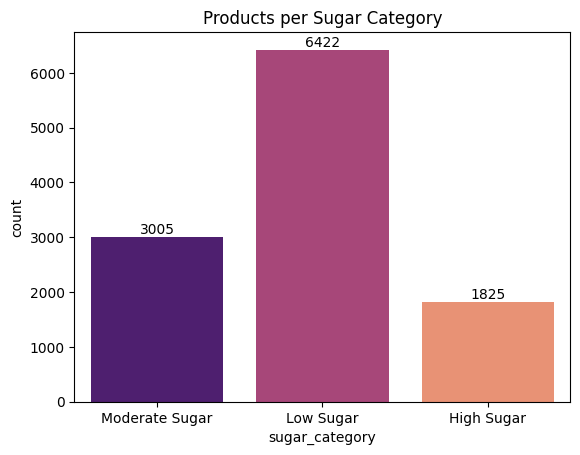

In [16]:
ax=sns.countplot(data=df, x='sugar_category', palette='magma')
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 50,
            int(height), ha="center", fontsize=10)

plt.title("Products per Sugar Category")
plt.show()

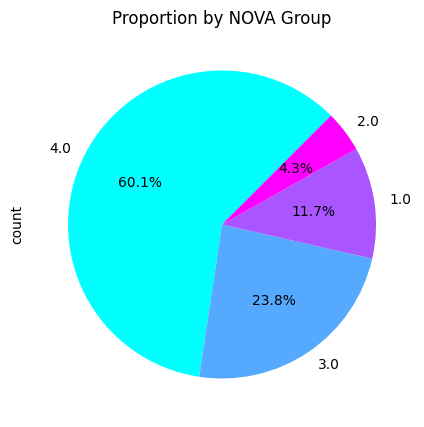

In [17]:
plt.figure(figsize=(8,5))
df['nova_group'].value_counts().plot.pie(autopct='%1.1f%%', startangle=45, cmap='cool')
plt.title("Proportion by NOVA Group")
# plt.ylabel("")
plt.show()